# Use Case 2 – Loan Default Risk Analysis

## Problem Statement

Build a machine learning model to identify customers with high probability of default risk based on financial behavior and historical data.

### Risk Indicators

- Default_History_Count
- Debt_to_Income_Ratio
- Existing_EMIs
- CIBIL_Score
- Employment_Length_Years
- Annual_Household_Income
- Loan_to_Annual_Income

### Target Variable

High_Risk = 1 if Default_History_Count > 0

High_Risk = 0 otherwise

### Evaluation Metrics

- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

In [1]:
# import libaries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Dataset Loading



In [4]:
data = pd.read_csv('/content/drive/MyDrive/Machine_Learning/datasets/preprocessed_hdfc_loan_data.csv')
data.shape

(1000, 48)

In [5]:
data.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0,0,31,1,0,2,0,1,56976,0,...,2,NaN,2,0,5,857743,6.939290e+11,9068671773,31,8
1,1,0,31,1,0,0,0,3,1856,0,...,0,NaN,2,5,15,863836,6.325430e+11,9990772625,31,2
2,2,0,1,0,1,0,0,1,64553,0,...,2,NaN,2,4,19,834796,1.658050e+11,9195085016,1,12
3,3,0,4,1,0,0,0,1,88450,0,...,0,NaN,2,1,27,438590,5.528183e+10,9179335548,4,11
4,4,0,11,1,1,3,0,2,9539,0,...,1,NaN,4,9,12,495224,1.557790e+11,9795137116,11,14


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   int64  
 1   Bank                         1000 non-null   int64  
 2   Customer_Name                1000 non-null   int64  
 3   Gender                       1000 non-null   int64  
 4   Married                      1000 non-null   int64  
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   int64  
 7   Employment_Status            1000 non-null   int64  
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

In [7]:
data.describe()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,...,1000.0000,0.0,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1.000000e+03,1000.000000,1000.000000
mean,499.500000,0.0,18.560000,0.673000,0.592000,0.849000,0.283000,1.42700,42430.057000,9727.11400,...,0.9710,NaN,2.241000,4.570000,13.916000,509976.40800,4.853271e+11,9.500193e+09,18.560000,8.689000
std,288.819436,0.0,12.660438,0.492253,0.491709,0.964951,0.450682,0.75845,28133.210769,20568.25945,...,0.8227,NaN,0.685119,2.828622,8.368212,289145.26265,2.925326e+11,2.875105e+08,12.660438,5.325847
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.0000,NaN,0.000000,0.000000,0.000000,622.00000,2.589553e+08,9.002443e+09,0.000000,0.000000
25%,249.750000,0.0,4.000000,0.000000,0.000000,0.000000,0.000000,1.00000,18260.000000,0.00000,...,0.0000,NaN,2.000000,2.000000,7.000000,263067.50000,2.192082e+11,9.254018e+09,4.000000,4.000000
50%,499.500000,0.0,18.000000,1.000000,1.000000,1.000000,0.000000,1.00000,40675.500000,0.00000,...,1.0000,NaN,2.000000,5.000000,14.000000,517643.50000,4.734835e+11,9.498140e+09,18.000000,9.000000
75%,749.250000,0.0,31.000000,1.000000,1.000000,2.000000,1.000000,2.00000,61037.250000,7956.50000,...,2.0000,NaN,2.000000,7.000000,21.000000,756922.00000,7.303725e+11,9.750462e+09,31.000000,13.000000
max,999.000000,0.0,40.000000,2.000000,1.000000,3.000000,1.000000,3.00000,149266.000000,123461.00000,...,2.0000,NaN,4.000000,9.000000,28.000000,998910.00000,9.990010e+11,9.999102e+09,40.000000,17.000000


# Create Derived Target Variable

Since the dataset does not contain a direct default risk column, a new target variable called High_Risk is created.

High_Risk = 1 if customer has previous defaults.

High_Risk = 0 otherwise.

In [8]:
data['High_Risk'] = np.where(
    data['Default_History_Count'] > 0,
    1,
    0
)

In [9]:
data['High_Risk'].value_counts()

,count
High_Risk,
0,906
1,94


In [ ]:
data[['Default_History_Count', 'High_Risk']].head()

,Default_History_Count,High_Risk
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


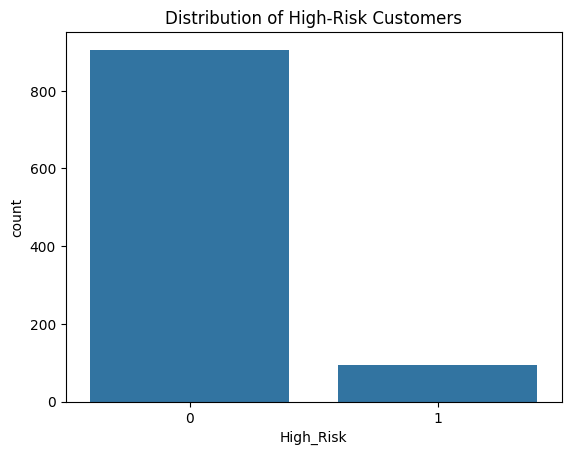

In [10]:
sns.countplot(
    x='High_Risk',
    data=data
)

plt.title("Distribution of High-Risk Customers")

plt.show()

# Feature Selection

Only features related to customer financial behavior are selected for default risk prediction.

In [11]:
features = [
    'Debt_to_Income_Ratio',
    'Existing_EMIs',
    'CIBIL_Score',
    'Employment_Length_Years',
    'Annual_Household_Income',
    'Loan_to_Annual_Income'
]

X = data[features]

y = data['High_Risk']

# Check Class Distribution

Analyze whether the dataset is balanced or imbalanced before model training.

In [12]:
y.value_counts()

,count
High_Risk,
0,906
1,94


# Train-Test Split

The dataset is divided into training and testing sets.

Stratified sampling is used to preserve the proportion of high-risk and low-risk customers in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Model Building

Three classification models are trained for default risk prediction:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

The models are evaluated using Recall, F1 Score, ROC-AUC, and Confusion Matrix.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [16]:
lr_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)


lr_model.fit(X_train_scaled, y_train)

rf_model.fit(X_train_scaled, y_train)

gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [18]:
y_pred_lr = lr_model.predict(X_test_scaled)

y_pred_rf = rf_model.predict(X_test_scaled)

y_pred_gb = gb_model.predict(X_test_scaled)

# Model Evaluation

The trained models are evaluated using:

- Accuracy
- Recall
- F1 Score
- ROC-AUC

Recall is considered the most important metric because identifying high-risk customers correctly is more critical than overall accuracy.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [21]:
comparison_results = []

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    comparison_results.append([
        name,
        accuracy_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        'Model',
        'Accuracy',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
)

comparison_df

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.905,0.0,0.0,0.659203
1,Random Forest,0.900,0.0,0.0,0.599302
2,Gradient Boosting,0.900,0.0,0.0,0.576621


# Confusion Matrix and Classification Report

A confusion matrix is used to visualize correct and incorrect classifications.

The classification report provides Precision, Recall and F1 Score for both classes.

In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

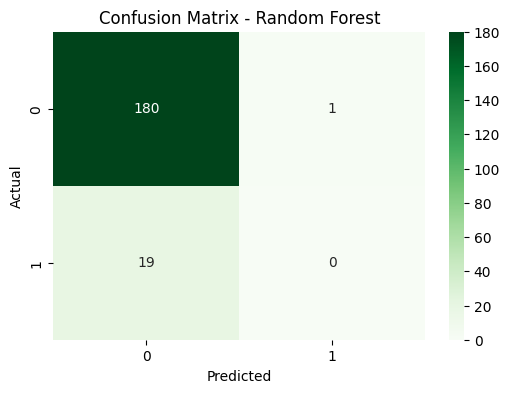

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [24]:
print("Logistic Regression\n")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest\n")
print(classification_report(y_test, y_pred_rf))

print("\nGradient Boosting\n")
print(classification_report(y_test, y_pred_gb))

Logistic Regression

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       181
           1       0.00      0.00      0.00        19

    accuracy                           0.91       200
   macro avg       0.45      0.50      0.48       200
weighted avg       0.82      0.91      0.86       200


Random Forest

              precision    recall  f1-score   support

           0       0.90      0.99      0.95       181
           1       0.00      0.00      0.00        19

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.82      0.90      0.86       200


Gradient Boosting

              precision    recall  f1-score   support

           0       0.90      0.99      0.95       181
           1       0.00      0.00      0.00        19

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
y.value_counts(normalize = True) *100

,proportion
High_Risk,
0,90.6
1,9.4


In [26]:
!pip install imbalanced-learn

In [27]:
#Applying SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [28]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

High_Risk
0    725
1     75
Name: count, dtype: int64
High_Risk
0    725
1    725
Name: count, dtype: int64


In [30]:
# retraining models using SMOTE data
# Logistic regression with SMOTE

lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [32]:
# Random forest with SMOTE

rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [31]:
# Gradient Boosting with SMOTE

gb_smote = GradientBoostingClassifier(random_state=42)

gb_smote.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(random_state=42)

In [34]:
# predict again with SMOTE models
rf_pred_smote = rf_smote.predict(X_test)

lr_pred_smote = lr_smote.predict(X_test)

gb_pred_smote = gb_smote.predict(X_test)

In [39]:
# Evaluating models

print("Logistic Regression with SMOTE\n")
print(classification_report(y_test, lr_pred_smote))

print("\nRandom Forest with SMOTE\n")
print(classification_report(y_test, rf_pred_smote))

print("\nGradient Boosting with SMOTE\n")
print(classification_report(y_test, gb_pred_smote))

Logistic Regression with SMOTE

              precision    recall  f1-score   support

           0       0.91      0.69      0.78       181
           1       0.10      0.32      0.15        19

    accuracy                           0.65       200
   macro avg       0.50      0.50      0.46       200
weighted avg       0.83      0.65      0.72       200


Random Forest with SMOTE

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       181
           1       0.14      0.26      0.18        19

    accuracy                           0.78       200
   macro avg       0.53      0.55      0.53       200
weighted avg       0.84      0.78      0.80       200


Gradient Boosting with SMOTE

              precision    recall  f1-score   support

           0       0.91      0.76      0.83       181
           1       0.10      0.26      0.15        19

    accuracy                           0.71       200
   macro avg       0.50      0.51     

In [40]:
rf_prob = rf_smote.predict_proba(X_test)[:,1]


In [41]:
roc_auc = roc_auc_score(y_test, rf_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6115149752835126


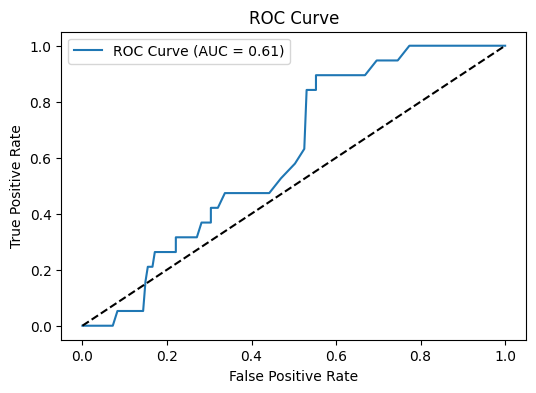

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# plotting ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Hyperparameter Tuning

GridSearchCV is used to identify the best parameter combinations for improving model performance.

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [48]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [49]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [50]:
print("Best Recall Score:")
print(grid_rf.best_score_)

Best Recall Score:
0.9117241379310345


In [51]:
best_rf = grid_rf.best_estimator_

In [ ]:
comparison_df

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.650,0.315789,0.146341,0.539692
1,Random Forest,0.775,0.263158,0.181818,0.611515
2,Gradient Boosting,0.710,0.263158,0.147059,0.600756


# Best Performing Model

Among the three models, Random Forest achieved the best overall performance and was selected as the final risk classification model.

# Feature Importance Analysis

Feature importance helps identify which financial factors contribute most to customer default risk.

In [52]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,CIBIL_Score,0.263087
5,Loan_to_Annual_Income,0.199798
4,Annual_Household_Income,0.194108
0,Debt_to_Income_Ratio,0.135554
1,Existing_EMIs,0.134140
3,Employment_Length_Years,0.073313


# Feature Importance Interpretation

The Random Forest model identified the following key factors influencing customer default risk:

1. CIBIL Score emerged as the most influential factor.
2. Annual Household Income significantly affects repayment capability.
3. Loan-to-Annual-Income ratio indicates the customer's debt burden.
4. Existing EMIs contribute to financial pressure.
5. Debt-to-Income Ratio reflects repayment capacity.
6. Employment Length Years has comparatively lower impact.

These insights can help banking teams identify risky customers and make better lending decisions.

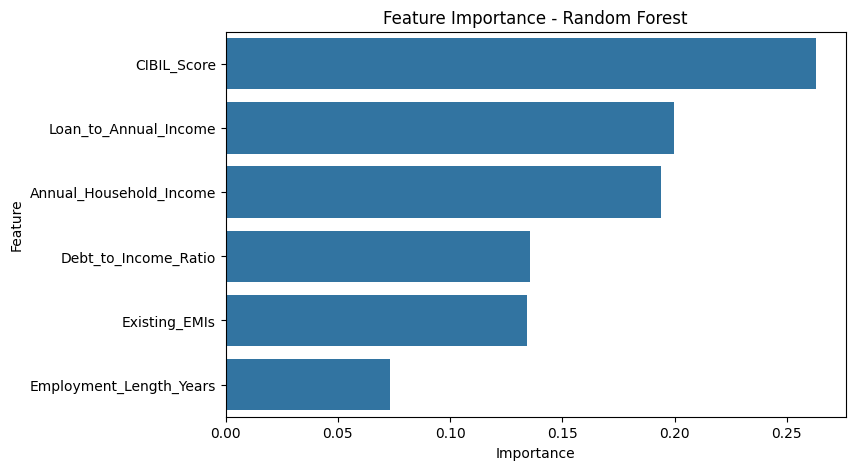

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

# High-Risk Customer Segment Analysis

Analyze characteristics of customers classified as high risk.

In [54]:
high_risk_customers = data[data['High_Risk'] == 1]

high_risk_customers.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation,High_Risk
10,10,0,32,0,1,0,1,2,25553,21419,...,NaN,2,3,13,39882,3.983430e+11,9637599805,32,13,1
13,13,0,21,1,0,1,1,2,17960,17074,...,NaN,1,1,0,140245,4.947870e+11,9714627301,21,5,1
16,16,0,4,1,1,1,0,1,29319,0,...,NaN,2,5,9,252997,5.202850e+11,9328338988,4,4,1
17,17,0,11,1,0,2,0,2,10609,0,...,NaN,4,2,18,871187,7.112080e+11,9852401322,11,10,1
23,23,0,40,1,0,0,0,1,97735,0,...,NaN,3,2,18,716329,3.539610e+11,9465796784,40,17,1


In [55]:
high_risk_customers[
    [
        'CIBIL_Score',
        'Debt_to_Income_Ratio',
        'Annual_Household_Income',
        'Existing_EMIs'
    ]
].mean()

,0
CIBIL_Score,603.446809
Debt_to_Income_Ratio,1.109223
Annual_Household_Income,635563.404255
Existing_EMIs,17301.819149


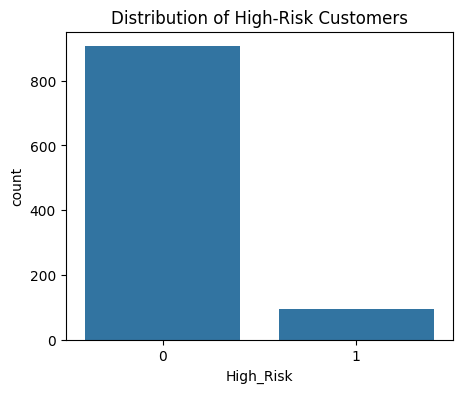

In [56]:
# Risk distribution

plt.figure(figsize=(5,4))

sns.countplot(
    x='High_Risk',
    data=data
)

plt.title("Distribution of High-Risk Customers")

plt.show()

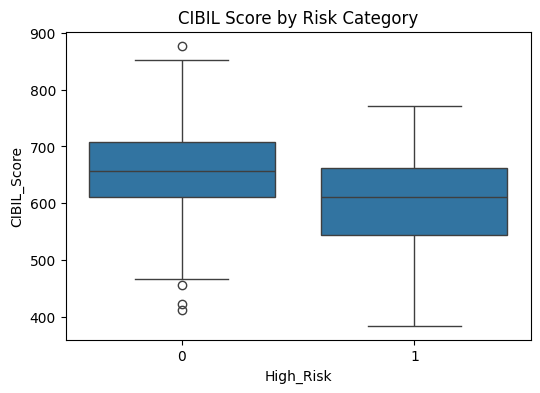

In [57]:
# CIBIL score VS Risk

plt.figure(figsize=(6,4))

sns.boxplot(
    x='High_Risk',
    y='CIBIL_Score',
    data=data
)

plt.title("CIBIL Score by Risk Category")

plt.show()

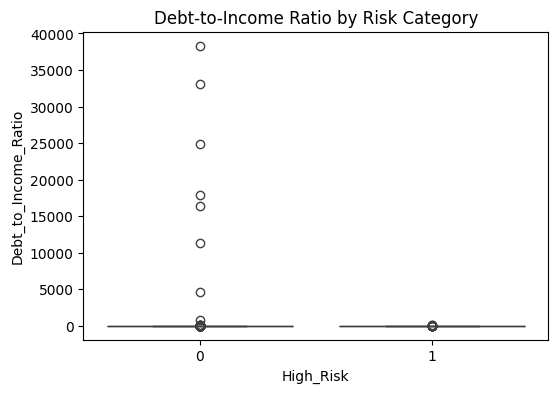

In [58]:
# Debt-to-income Ratio VS Risk

plt.figure(figsize=(6,4))

sns.boxplot(
    x='High_Risk',
    y='Debt_to_Income_Ratio',
    data=data
)

plt.title("Debt-to-Income Ratio by Risk Category")

plt.show()

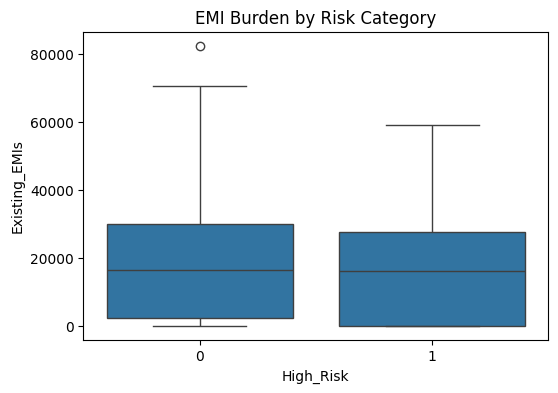

In [59]:
# EMI burden analysis

plt.figure(figsize=(6,4))

sns.boxplot(
    x='High_Risk',
    y='Existing_EMIs',
    data=data
)

plt.title("EMI Burden by Risk Category")

plt.show()

<Figure size 600x400 with 0 Axes>

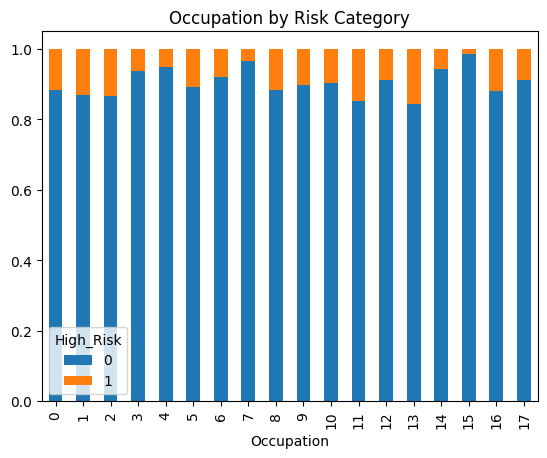

In [65]:
# occupation risk analysis

occupation_risk  = pd.crosstab(
    index=data['Occupation'],
    columns=data['High_Risk'],
    normalize='index'
)

plt.figure(figsize=(6,4))

occupation_risk.plot(
    kind='bar',
    stacked=True
)


plt.title("Occupation by Risk Category")

plt.show()

<Figure size 600x400 with 0 Axes>

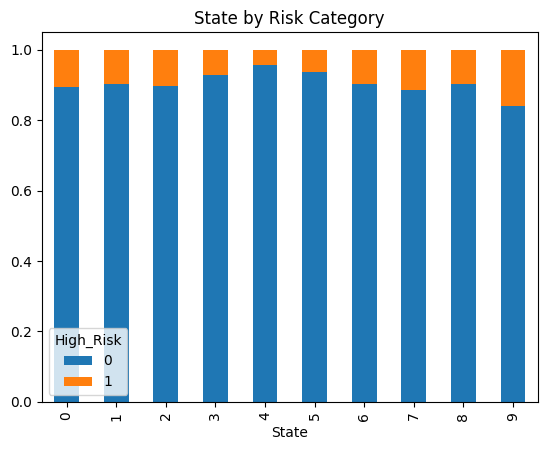

In [66]:
# statewise risk analysis

state_risk = pd.crosstab(
    index=data['State'],
    columns=data['High_Risk'],
    normalize='index'
)

plt.figure(figsize=(6,4))

state_risk.plot(
    kind='bar',
    stacked=True
)

plt.title("State by Risk Category")

plt.show()


# Model Persistence

The final tuned Random Forest model is saved using Joblib so that it can be reused later without retraining.

In [67]:
import joblib

joblib.dump(
    best_rf,
    '/content/drive/MyDrive/Machine_Learning/models/loan_default_risk_model.pkl'
)

['/content/drive/MyDrive/Machine_Learning/models/loan_default_risk_model.pkl']

# Conclusion

A Loan Default Risk Classification model was developed to identify customers with a high probability of default.

Key observations:

- Class imbalance was handled using SMOTE.
- Multiple models were trained and compared.
- Random Forest achieved the best overall performance.
- Hyperparameter tuning was performed using GridSearchCV.
- Feature importance analysis identified CIBIL Score and Annual Household Income as major contributors to default risk.
- The final tuned model was saved for future deployment.

These insights can help banking teams proactively identify risky customers and improve lending decisions.